In [1]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
import seaborn as sns

import json
import os
BASE_DIR = '.'

import glob
import pandas as pd

In [2]:
# general matplotlblib settings
axthickness = 1.5
axticklength = 5
rcParams["ytick.major.size"] = axticklength
rcParams["xtick.major.size"] = axticklength
rcParams["text.usetex"]=False
rcParams['axes.linewidth'] = axthickness
plt.rcParams['xtick.major.width'] = axthickness
plt.rcParams['ytick.major.width'] = axthickness


# Load CSV Dataframes

In [3]:
# main functions to import from src
from src import GGB_Statements,  get_model_shortname
from analysis_functions import load_and_clean_single_run, get_agent_shortname
from analysis_functions import star_csv_to_df

Questions already have IDs


## Questions

In [4]:
QUESTION_JSON = os.path.abspath('GGB_benchmark/GreatestGoodBenchmark.json') 
Inverted_JSON = os.path.abspath('GGB_benchmark/GreatestGoodBenchmarkInverted.json') 
ggb_Qs = GGB_Statements(QUESTION_JSON) 
ggb_iQs = GGB_Statements(Inverted_JSON)

## Singles

In [5]:
single_csvs = glob.glob('results/single_ggb**_q1-90_n12.csv')
#####################
##### single_df #####
#####################
single_df = pd.DataFrame()

for irun, runcsv in enumerate(single_csvs):
    if 'inverted' in runcsv.lower():
        Qs = ggb_iQs
        label = 'GGB_inverted'
    else:
        Qs = ggb_Qs
        label = 'GGB'

    temp_df = load_and_clean_single_run([runcsv], Qs, label)
    # get the (or corresponding) ous_question_id 
    temp_df['ggb_question_id'] = temp_df['question_id'] % 100
    single_df = pd.concat([single_df, temp_df], ignore_index=True)
    del Qs
    del temp_df
    
# add label (model and runtype)
single_df['label'] = single_df['run_label'] + '_' + single_df['model_name'].apply(get_model_shortname)

######################################################
##### single_by_question  and single_by_category #####
######################################################
# Convert answer column to numeric, coercing errors to NaN
single_df['answer_numeric'] = pd.to_numeric(single_df['answer'], errors='coerce')

# Take out off-topic answers
single_df = single_df[single_df['is_response_off_topic'] == False]

# Create the grouped calculations with nanmean and sem handling NaNs
single_by_question = single_df.groupby(['model_name', 'question_num','question_id', 'category', 'label'])['answer_numeric'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x))))
]).reset_index()

# (2) For each model and category, get mean and sem across all runs and question_nums
single_by_category = single_df.groupby(['model_name', 'category', 'label'])['answer_numeric'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x))))
]).reset_index()

Processing results/single_ggb_inverted_group_prompt_anthropic_claude-3.5-haiku_q1-90_n12.csv
  Filtered 0 off-topic responses from results/single_ggb_inverted_group_prompt_anthropic_claude-3.5-haiku_q1-90_n12.csv based on results/single_ggb_inverted_group_prompt_anthropic_claude-3.5-haiku_q1-90_n12_classification.jsonl.
  Classification coverage: 1080/1080 (100.0%)

=== SINGLE RUN CLASSIFICATION COVERAGE SUMMARY ===
Total files processed: 1
Total responses across all files: 1,080
Responses with classifications: 1,080
Missing classifications: 0
Overall classification coverage: 100.0%
Processing results/single_ggb_inverted_group_prompt_qwen_qwen-2.5-7b-instruct_q1-90_n12.csv
  Filtered 0 off-topic responses from results/single_ggb_inverted_group_prompt_qwen_qwen-2.5-7b-instruct_q1-90_n12.csv based on results/single_ggb_inverted_group_prompt_qwen_qwen-2.5-7b-instruct_q1-90_n12_classification.jsonl.
  Classification coverage: 1080/1080 (100.0%)

=== SINGLE RUN CLASSIFICATION COVERAGE SUMMA

/Users/oshun/Documents/GitHub/wisdom_agents/.conda/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## Round Robin

In [6]:
ring_csvs = glob.glob('results_multi/ggb_**_ensemble_**_q1-90_n12.csv')
# from parquet files 
preprocessed_dir = "preprocessed"
ring_df_path = os.path.join(preprocessed_dir, "ring_df.parquet")
ring_rr_df_path = os.path.join(preprocessed_dir, "ring_rr_df.parquet")

######################
##### ring_rr_df #####
######################
# Check if preprocessed files exist
if os.path.exists(ring_df_path) and os.path.exists(ring_rr_df_path):
    print("Loading preprocessed ring data...")
    ring_df = pd.read_parquet(ring_df_path)
    ring_rr_df = pd.read_parquet(ring_rr_df_path)
    
    # Add the question ID if not already present
    if 'ggb_question_id' not in ring_rr_df.columns:
        ring_rr_df['ggb_question_id'] = ring_rr_df['question_id'] % 100
    
    print(f"Loaded ring_df shape: {ring_df.shape}")
    print(f"Loaded ring_rr_df shape: {ring_rr_df.shape}")
    print(f"Sample of ring_rr_df columns: {ring_rr_df.columns.tolist()}")
    
else:
    print("Preprocessed files not found.")

ring_rr_df = ring_rr_df[ring_rr_df['is_response_off_topic']==False]
##########################
##### rr_by_agent_df #####
##########################
# Get the answers by each agent
rr_by_agent_df = ring_rr_df.copy()
rr_by_agent_df['agent_shortname']  = rr_by_agent_df['agent_name'].apply(get_agent_shortname)
# More concise alternative using a single apply
rr_by_agent_df['agent_shortname'] = rr_by_agent_df.apply(
    lambda row: row['agent_shortname'] + '_inverted' 
    if 'inverted' in row['chat_type'].lower() 
    else row['agent_shortname'], 
    axis=1)

######################################
##### ring_by_category_and_model #####
######################################
ring_by_category_and_model = rr_by_agent_df.groupby(['agent_shortname', 'category','round'])['agent_answer'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x))))
    ]).reset_index()

#############################
##### ring_by_question #####
#############################
ring_by_question = ring_rr_df.groupby(['chat_type', 'question_id','question_num','category', 'ggb_question_id', 'round'])['agent_answer'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x))))
]).reset_index()

#############################
##### ring_by_category #####
#############################
ring_by_category = ring_rr_df.groupby(['chat_type', 'category', 'round'])['agent_answer'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x))))
]).reset_index()

Loading preprocessed ring data...
Loaded ring_df shape: (362856, 15)
Loaded ring_rr_df shape: (362856, 17)
Sample of ring_rr_df columns: ['question_id', 'question_num', 'category', 'run_index', 'chat_type', 'config_details', 'round', 'agent_name', 'agent_answer', 'agent_confidence', 'full_response', 'message_index', 'repeat_index', 'ggb_question_id', 'selected_categories', 'is_response_off_topic', 'off_topic_reason']


/var/folders/q6/kbk4hvwn5cl2y361hyy37_cr0000gp/T/ipykernel_92409/3453786653.py:54: RuntimeWarning: Mean of empty slice
  ('mean', lambda x: np.nanmean(x)),
/Users/oshun/Documents/GitHub/wisdom_agents/.conda/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## Star

In [ ]:
star_csvs = glob.glob('results_multi_star/**_star_super**_q1-90_1n2.csv')
evilstar_csvs = glob.glob('results_multi_star/**_star_evil**_q1-90_n12.csv')
all_star_csvs = glob.glob('results_multi_star/**star**_q1-90_n12.csv')

star_dfs = []
for csv_file in all_star_csvs:
    if 'inverted' in csv_file:
        current_Qs = ggb_iQs
    else:
        current_Qs = ggb_Qs
    
    df = star_csv_to_df(csv_file, current_Qs, csv_file)
    star_dfs.append(df)
    del df
    del current_Qs

star_df = pd.concat(star_dfs, ignore_index=True)

# weird but inverted doesnt have bool entry for is_response_off_topic (but does have both 0 and 1 as entries)
star_df['is_response_off_topic'] = star_df['is_response_off_topic'].apply(lambda x: bool(x) if type(x) != bool else x)
star_df = star_df[star_df['is_response_off_topic']==False]
star_df['ggb_question_id'] = star_df['question_id'].apply(lambda x: x % 100)

star_label_map = {'ggb_star_evil_supervisor_gpt-4o-mini': 'RT Star',
                  'ggb_star_supervisor_gpt-4o-mini' : 'Star GPT',
                  'ggb_star_supervisor_gpt-4o-mini_inverted': 'Star GPT Inverted',
                  'ggb_star_supervisor_qwen-2.5-7b-instruct': 'Star Qwen'}

star_df['label'] = star_df['chat_type'].apply(lambda x: star_label_map[x])


#############################
##### star_by_question #####
#############################
star_by_question = star_df.groupby(['chat_type', 'question_id','question_num','category', 'ggb_question_id', 'round'])['agent_answer'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x))))
]).reset_index()

#############################
##### star_by_category #####
#############################
star_by_category = star_df.groupby(['chat_type', 'category', 'round', 'label'])['agent_answer'].agg([
    ('mean', lambda x: np.nanmean(x)),
    ('std',  lambda x: np.nanstd(x, ddof=1)),
    ('sem', lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.sum(~np.isnan(x))))
]).reset_index()

  Classification coverage: 25919/25920 (100.0%)
  Missing classifications: 1 responses
  Classification coverage: 25903/25903 (100.0%)
  Classification coverage: 25834/25834 (100.0%)
  Classification coverage: 25771/25772 (100.0%)
  Missing classifications: 1 responses


# Plot IH v IB

In [ ]:
# colors 
tol_muted = {
    'Qwen': '#117733',      # Qwen
    'Claude': '#44AA99',       # Claude
    'DeepSeek': '#88CCEE',    # Deepseek
    'LinCombo': '#DDCDDD',  # \sum_{ISOLATED} 
    'pink': '#AA4499',  
    'RT Star': '#882255',     # Evil Star (GPT) 
    'GPT': '#CC6677',     # GPT
    'Gemini': '#999933',       # Gemini
    'Hetero': '#DDCC77',     # Hetero
    'Llama': '#332288'        # Llama   
}

# legend labels (do not uncomment)
# legend_labels = ['Claude', 'DeepSeek', 'Gemini', 'Llama', 'GPT', 'Qwen', 'Hetero', 'Evil', 'LinCombo']
# legend_labels = ['Claude', 'DeepSeek', 'Gemini', 'Llama', 'GPT', 'Qwen', 'Hetero', 'LinCombo', 'Inverted', 'Star', 'Evil Star']


In [9]:
from mpl_toolkits.axes_grid1 import Divider, Size
from visualization_functions import h2, human_kde

## single labels mapping

In [10]:
list(single_by_category.label.unique())

['GGB_claude',
 'GGB_inverted_claude',
 'GGB_deepseek',
 'GGB_inverted_deepseek',
 'GGB_gemini',
 'GGB_inverted_gemini',
 'GGB_inverted_llama',
 'GGB_llama',
 'GGB_gpt',
 'GGB_inverted_gpt',
 'GGB_inverted_qwen',
 'GGB_qwen']

In [11]:
# df to plot labels and colors
single_plot_df = single_by_category.copy()
df_labels = ['GGB_claude','GGB_inverted_claude', 'GGB_deepseek',
       'GGB_inverted_deepseek', 'GGB_gemini', 'GGB_inverted_gemini',
       'GGB_inverted_llama', 'GGB_llama', 'GGB_gpt', 'GGB_inverted_gpt',
       'GGB_inverted_qwen', 'GGB_qwen'] # list(single_by_category.model_name.unique())


plot_labels = ['Claude', 'Inverted Claude', 'DeepSeek',
       'Inverted DeepSeek', 'Gemini', 'Inverted Gemini',
       'Inverted Llama', 'Llama', 'GPT', 'Inverted GPT',
       'Inverted Qwen', 'Qwen']
df_to_plot_label = dict(zip(df_labels, plot_labels))


##########################
##### single_plot_df #####
##########################
single_plot_df['plot_label'] = single_plot_df['label'].apply(lambda x: df_to_plot_label[x])

## Round Robin label mapping (and round 4 selection)

In [12]:
ring_name_mapping = {
    'ggb_claude-3.5-haiku_ring': 'Claude', 
    'ggb_inverted_claude_ring' : 'Inverted Claude',
    'ggb_gpt_ring' : 'GPT',
    'ggb_inverted_gpt_ring': 'Inverted GPT',
    'ggb_deepseek-chat-v3-0324_ring' : 'DeepSeek',
    'ggb_deepseek-chat-v3-0324_ring_inverted' : 'Inverted DeepSeek',
    'ggb_llama-3.1-8b-instruct_ring' : 'Llama',
    'ggb_llama-3.1-8b-instruct_ring_inverted': 'Inverted Llama',
    'ggb_inverted_qwen_ring' : 'Inverted Qwen',
    'ggb_qwen-2.5-7b-instruct_ring': 'Qwen',
    'ggb_hetero_ring' : 'Hetero', 
    'ggb_inverted_hetero_ring' : 'Inverted Hetero', 
    'ggb_inverted_gemini_ring' : 'Inverted Gemini',
    'ggb_gemini_ring' : 'Gemini'
    }

ring_labeled_df = ring_by_category.copy()
ring_labeled_df['plot_label'] = ring_labeled_df['chat_type'].apply(lambda x: ring_name_mapping.get(x, x))
rr_plot_df = ring_labeled_df[ring_labeled_df['round'] == 4]

## Star label mapping and round 4 selection

In [ ]:
star_plot_rr = star_by_category[star_by_category['round']==4].copy()

star_labels = ['RT Star', 'Star GPT', 'Star GPT Inverted', 'Star Qwen']
star_plot_labels = ['RT Star (GPT)', 'GPT', 'Inverted GPT', 'Qwen']
star_plot_mapping = dict(zip(star_labels, star_plot_labels))
star_plot_rr['plot_label'] = star_plot_rr['label'].apply(lambda x: star_plot_mapping.get(x, x))

In [14]:
star_plot_rr

,chat_type,category,round,label,mean,std,sem,plot_label
3,ggb_star_evil_supervisor_gpt-4o-mini,IB,4.0,Evil Star,6.214825,0.953745,0.015951,RT Star (GPT)
7,ggb_star_evil_supervisor_gpt-4o-mini,IH,4.0,Evil Star,2.489493,2.367450,0.045064,RT Star (GPT)
11,ggb_star_supervisor_gpt-4o-mini,IB,4.0,Star GPT,6.046840,0.988535,0.016605,GPT
15,ggb_star_supervisor_gpt-4o-mini,IH,4.0,Star GPT,1.894998,1.909867,0.035971,GPT
19,ggb_star_supervisor_gpt-4o-mini_inverted,IB,4.0,Star GPT Inverted,4.056294,2.096687,0.035265,Inverted GPT
23,ggb_star_supervisor_gpt-4o-mini_inverted,IH,4.0,Star GPT Inverted,3.940455,2.584106,0.048362,Inverted GPT
27,ggb_star_supervisor_qwen-2.5-7b-instruct,IB,4.0,Star Qwen,5.800712,1.128378,0.019432,Qwen
31,ggb_star_supervisor_qwen-2.5-7b-instruct,IH,4.0,Star Qwen,1.873070,1.778231,0.034511,Qwen


/var/folders/q6/kbk4hvwn5cl2y361hyy37_cr0000gp/T/ipykernel_92409/3103446704.py:190: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ih_inverted  = star_plot_rr[(star_plot_rr['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IH')]
/var/folders/q6/kbk4hvwn5cl2y361hyy37_cr0000gp/T/ipykernel_92409/3103446704.py:195: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ib_inverted  = star_plot_rr[(star_plot_rr['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IB')]


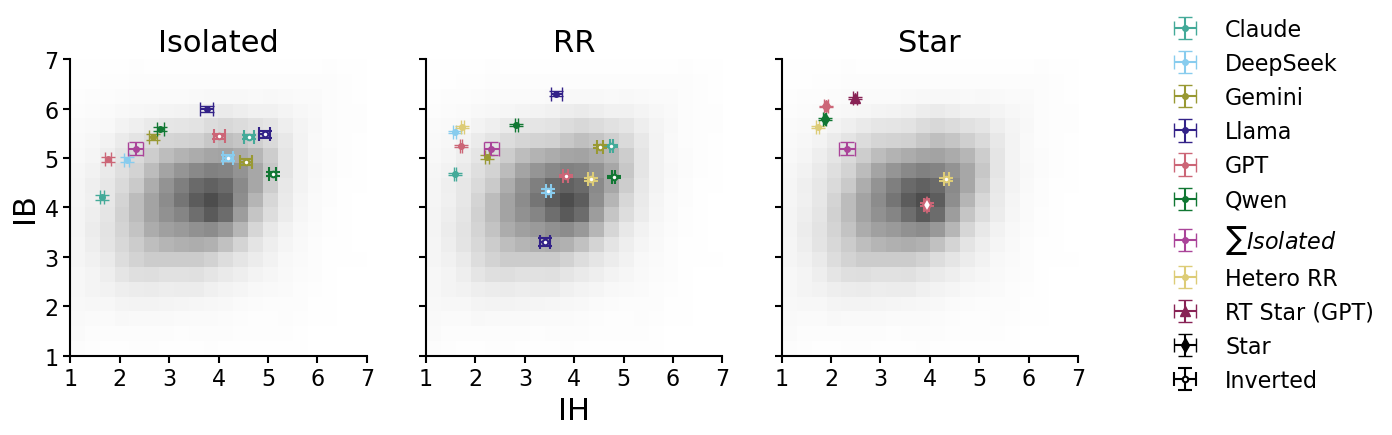

In [ ]:
text_size = 22
tick_size = 16
capsize = 5
markersize = 4

# original with legend 
fig, ax = plt.subplots(nrows=1, ncols= 3, figsize=(13, 5), sharey=True, sharex=True)
# # for just the plots (no legend)
# fig, ax = plt.subplots(nrows=1, ncols= 3, figsize=(10.25, 5), sharey=True, sharex=True)

# titles
ax[0].set_title('Isolated', fontsize=text_size)
ax[1].set_title('RR',fontsize=text_size)
ax[2].set_title('Star',fontsize=text_size)
ax[0].set_ylabel('IB',fontsize=text_size)
ax[1].set_xlabel('IH',fontsize=text_size)

# human kde
[human_kde(human_df=h2, ax=a, alpha=0.7) for a in ax]

# Ticks and spines
[a.set_xlim(1, 7) for a in ax]
[a.set_xticks([1, 2, 3, 4, 5, 6, 7]) for a in ax]
[a.set_ylim(1, 7) for a in ax]
[a.set_yticks([1, 2, 3, 4, 5, 6, 7]) for a in ax]
[a.spines['top'].set_visible(False) for a in ax]
[a.spines['right'].set_visible(False) for a in ax]
[a.tick_params(axis='both', which='major', labelsize=tick_size)  for a in ax]


####################
#### plot singles
####################
single_models = ['Claude', 'DeepSeek', 'Gemini', 'Llama', 'GPT', 'Qwen']
# For each model, get data for both categories and plot
for m in single_models:
       # Get IH data for this model (and for inverted)
       ih_data = single_plot_df[(single_plot_df['plot_label'] == m) & (single_plot_df['category'] == 'IH')]
       ih_inverted  = single_plot_df[(single_plot_df['plot_label'] == 'Inverted ' + m) & (single_plot_df['category'] == 'IH')]
       ih_mean = ih_data['mean'].values[0]
       ih_sem = ih_data['sem'].values[0]
       ih_inverted_mean = ih_inverted['mean'].values[0] 
       ih_inverted_sem = ih_inverted['sem'].values[0]

       # Get IB data for this model (and for inverted)
       ib_data = single_plot_df[(single_plot_df['plot_label'] == m) & (single_plot_df['category'] == 'IB')]
       ib_inverted  = single_plot_df[(single_plot_df['plot_label'] == 'Inverted ' + m) & (single_plot_df['category'] == 'IB')]
       ib_mean = ib_data['mean'].values[0]
       ib_sem = ib_data['sem'].values[0]
       ib_inverted_mean = ib_inverted['mean'].values[0]
       ib_inverted_sem = ib_inverted['sem'].values[0]

       # Get color from our mapping
       color = tol_muted[m]

       # Use the same marker outline color but different fill based on inverted status
       ax[0].errorbar(
              ih_mean, ib_mean,
              xerr=ih_sem, yerr=ib_sem, 
              fmt='o', color=color, 
              markerfacecolor=color,    # Filled with color
              markeredgecolor=color,
              label=m, capsize=capsize,
              markersize=markersize
              )
       
       # Plot inverted with white fill and colored outline
       ax[0].errorbar(
              ih_inverted_mean, ib_inverted_mean,
              xerr=ih_inverted_sem, yerr=ib_inverted_sem, 
              fmt='o', color=color, markerfacecolor='white',  # White fill
              markeredgecolor=color,    # Color outline
              markeredgewidth=1.5,      # Thicker outline
              label=None, capsize=capsize,
              markersize=markersize
              )



########################
#### plot Round Robins
########################
rr_topologies = ['Claude', 'DeepSeek', 'Gemini', 'Llama', 'GPT', 'Qwen', 'Hetero']

# For each model, get data for both categories and plot
for m in rr_topologies:
       
       # Get IH data for this model (and for inverted)
       ih_data = rr_plot_df[(rr_plot_df['plot_label'] == m) & (rr_plot_df['category'] == 'IH')]
       ih_inverted  = rr_plot_df[(rr_plot_df['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IH')]
       ih_mean = ih_data['mean'].values[0]
       ih_sem = ih_data['sem'].values[0]
       ih_inverted_mean = ih_inverted['mean'].values[0] 
       ih_inverted_sem = ih_inverted['sem'].values[0]

       # Get IB data for this model (and for inverted)
       ib_data = rr_plot_df[(rr_plot_df['plot_label'] == m) & (rr_plot_df['category'] == 'IB')]
       ib_inverted  = rr_plot_df[(rr_plot_df['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IB')]
       ib_mean = ib_data['mean'].values[0]
       ib_sem = ib_data['sem'].values[0]
       ib_inverted_mean = ib_inverted['mean'].values[0]
       ib_inverted_sem = ib_inverted['sem'].values[0]

       # Get color from our mapping
       color = tol_muted[m]

       # If Hetero, also plot in the third axis and label for legend
       if m == 'Hetero':
              ax[2].errorbar(
                     ih_mean, ib_mean,
                     xerr=ih_sem, yerr=ib_sem, 
                     fmt='o', color=color, 
                     markerfacecolor=color,    # Filled with color
                     markeredgecolor=color,
                     label='Hetero RR', capsize=capsize,
                     markersize=markersize
                     )
              ax[2].errorbar(
                     ih_inverted_mean, ib_inverted_mean,
                     xerr=ih_inverted_sem, yerr=ib_inverted_sem, 
                     fmt='o', color=color, markerfacecolor='white',  # White fill
                     markeredgecolor=color,    # Color outline
                     markeredgewidth=1.5,      # Thicker outline
                     label=None, capsize=capsize,
                     markersize=markersize
                     )
              
       # Use the same marker outline color but different fill based on inverted status
       ax[1].errorbar(
              ih_mean, ib_mean,
              xerr=ih_sem, yerr=ib_sem, 
              fmt='o', color=color, 
              markerfacecolor=color,    # Filled with color
              markeredgecolor=color,
              label=None, capsize=capsize,
              markersize=markersize
              )
       
       # Plot inverted with white fill and colored outline
       ax[1].errorbar(
              ih_inverted_mean, ib_inverted_mean,
              xerr=ih_inverted_sem, yerr=ib_inverted_sem, 
              fmt='o', color=color, markerfacecolor='white',  # White fill
              markeredgecolor=color,    # Color outline
              markeredgewidth=1.5,      # Thicker outline
              label=None, capsize=capsize,
              markersize=markersize
              )
       
########################
#### plot Star
########################
star_marker = 'd'
star_marker_size = 7
star_capsize = 5
star_topologies = ['RT Star (GPT)', 'GPT', 'Qwen']
star_markers = dict(zip(star_topologies, ['^', star_marker, star_marker]))  


for m in star_topologies:
       # Get IH data for this model (and for inverted)
       ih_data = star_plot_rr[(star_plot_rr['plot_label'] == m) & (star_plot_rr['category'] == 'IH')]
       ih_mean = ih_data['mean'].values[0]
       ih_sem = ih_data['sem'].values[0]

       # Get IB data for this model (and for inverted)
       ib_data = star_plot_rr[(star_plot_rr['plot_label'] == m) & (star_plot_rr['category'] == 'IB')]
       ib_mean = ib_data['mean'].values[0]
       ib_sem = ib_data['sem'].values[0]


       marker_style = star_markers[m]
       if m == 'RT Star (GPT)':
              color = tol_muted['RT Star']
              # Use the same marker outline color but different fill based on inverted status
              ax[2].errorbar(
                     ih_mean, ib_mean,
                     xerr=ih_sem, yerr=ib_sem, 
                     fmt=marker_style, color=color, 
                     markerfacecolor=color,    # Filled with color
                     markeredgecolor=color,
                     label=m, capsize=star_capsize,
                     markersize=star_marker_size
                     )
       else: 
              color = tol_muted[m]
              if m == 'GPT': 
                     # plot inverted
                     # Get IH data for this model (and for inverted)
                     ih_inverted  = star_plot_rr[(star_plot_rr['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IH')]
                     ih_inverted_mean = ih_inverted['mean'].values[0]
                     ih_inverted_sem = ih_inverted['sem'].values[0]

                     # Get IB data for this model (and for inverted)
                     ib_inverted  = star_plot_rr[(star_plot_rr['plot_label'] == 'Inverted ' + m) & (rr_plot_df['category'] == 'IB')]
                     ib_inverted_mean = ib_inverted['mean'].values[0]
                     ib_inverted_sem = ib_inverted['sem'].values[0]

                     # Plot inverted with white fill and colored outline
                     ax[2].errorbar(
                            ih_inverted_mean, ib_inverted_mean,
                            xerr=ih_inverted_sem, yerr=ib_inverted_sem, 
                            fmt=marker_style, color=color, markerfacecolor='white',  # White fill
                            markeredgecolor=color,    # Color outline
                            markeredgewidth=1.5,      # Thicker outline
                            label=None, capsize=star_capsize,
                            markersize=star_marker_size
                            )

              # Use the same marker outline color but different fill based on inverted status
              ax[2].errorbar(
                     ih_mean, ib_mean,
                     xerr=ih_sem, yerr=ib_sem, 
                     fmt=marker_style, color=color, 
                     markerfacecolor=color,    # Filled with color
                     markeredgecolor=color,
                     label=None, capsize=capsize,
                     markersize=1.5*markersize
                     )

####################
#### plot extras
####################
# General star 
ax[2].errorbar(
              8, 8,
              xerr=1e3, yerr=1e3, 
              fmt=star_marker, color='black', 
              markerfacecolor='black',    # Filled with color
              markeredgecolor='black',
              label='Star', capsize=star_capsize,
              markersize=star_marker_size
              )


# Linear combination of singles (LinCombo) 
y_ib = 5.192746    
y_ib_error = 0.130093
x_ih = 2.323340    
x_ih_error = 0.154879
LC_color = tol_muted['pink']

ax[0].errorbar(
       x_ih, y_ib,
       xerr=x_ih_error, yerr=y_ib_error, 
       fmt='o', color=LC_color, markerfacecolor=LC_color,  # White fill
       markeredgecolor=LC_color,    # Color outline
       label=r'$\sum{Isolated}$', capsize=capsize,
       markersize=markersize
       )
ax[1].errorbar(
       x_ih, y_ib,
       xerr=x_ih_error, yerr=y_ib_error, 
       fmt='o', color=LC_color, markerfacecolor=LC_color,  # White fill
       markeredgecolor=LC_color,    # Color outline
       label=None, capsize=capsize,
       markersize=markersize
       )
ax[2].errorbar(
       x_ih, y_ib,
       xerr=x_ih_error, yerr=y_ib_error, 
       fmt='o', color=LC_color, markerfacecolor=LC_color,  # White fill
       markeredgecolor=LC_color,    # Color outline
       label=None, capsize=capsize,
       markersize=markersize
       )

# Add generic outside axis limits for legend
# Inverted
ax[2].errorbar(
       8, 8,
       xerr=1e3, yerr=1e3, 
       fmt='o', color= 'black', markerfacecolor='white',  # White fill
       markeredgecolor= 'black',    # Color outline
       markeredgewidth=1.5,      # Thicker outline
       label='Inverted', capsize=capsize,
       markersize=markersize
       )


fig.legend(loc= 'center left',  #'upper center',        # Align by upper center
                bbox_to_anchor= (.95, 0.5), #(0.5, -0.16), # Position below axes (x=center, y=below)
                frameon=False, 
                fontsize=tick_size)
                
              
              
              
ax[0].set_aspect(1, share=True) # equal aspect ratio for all subplots

fig.savefig('figures/poster_IHvIB.svg', bbox_inches='tight')

# LaaJ - Methods (off-topic) and Results (all rationale)

## load all classification data

In [16]:
topologies = {
    "Single-Agent": os.path.join(BASE_DIR, "results"),
    "Multi-Agent": os.path.join(BASE_DIR, "results_multi"),
    "Star-Topology": os.path.join(BASE_DIR, "results_multi_star")
}

all_classification_data = []
for topo_name, dir_path in topologies.items():
    if os.path.exists(dir_path):
        for fpath in glob.glob(os.path.join(dir_path, "*_classification.jsonl")):
            try:
                dfj = pd.read_json(fpath, lines=True)
                if "selected_categories" in dfj.columns:
                    dfj['topology'] = topo_name
                    # Add dataset column with the filename (without path and extension)
                    dataset_name = os.path.basename(fpath).replace('_classification.jsonl', '')
                    dfj['dataset'] = dataset_name
                    all_classification_data.append(dfj)
            except Exception as e:
                print(f"Error loading {fpath}: {e}")

## combined_df and exploded df

In [17]:
# =============================================================================
# FROM RAM'S HEATMAPS FOR AGENT-SPECIFIC ANALYSIS (WITH ABSOLUTE FREQUENCIES)
# =============================================================================

# Standardize columns across all classification dataframes before concatenation
for i, df in enumerate(all_classification_data):
    # Add message_index if missing, default to 0
    if 'message_index' not in df.columns:
        df['message_index'] = 0
    
    # Map extracted_answer to answer if needed
    if 'extracted_answer' in df.columns and 'answer' not in df.columns:
        df['answer'] = df['extracted_answer']
    elif 'extracted_answer' in df.columns and 'answer' in df.columns:
        # If both exist, prioritize extracted_answer
        df['answer'] = df['extracted_answer']
    
    # Map extracted_confidence to confidence if needed
    if 'extracted_confidence' in df.columns and 'confidence' not in df.columns:
        df['confidence'] = df['extracted_confidence']
    elif 'extracted_confidence' in df.columns and 'confidence' in df.columns:
        # If both exist, prioritize extracted_confidence
        df['confidence'] = df['extracted_confidence']
    
    # Map agent_model to model_name if needed
    if 'agent_model' in df.columns and 'model_name' not in df.columns:
        df['model_name'] = df['agent_model']
    elif 'agent_model' in df.columns and 'model_name' in df.columns:
        # If both exist, prioritize agent_model
        df['model_name'] = df['agent_model']

print(f"Standardized {len(all_classification_data)} classification dataframes")

# Combine all classification data
combined_df = pd.concat(all_classification_data, ignore_index=True)

# Create exploded dataframe for accurate category counting (now happens later)
# exploded_df = combined_df.explode("selected_categories")
# exploded_df = exploded_df[exploded_df['selected_categories'].notna()]

# Add question classification columns based on question_id ranges
def classify_question(question_id):
    if 1 <= question_id  <= 40:
        return False, 'IH'
    elif 41 <= question_id <= 90:
        return False, 'IB'
    elif 101 <= question_id <= 140:
        return True, 'IH'
    elif 141 <= question_id <= 190:
        return True, 'IB'
    else:
        return None, None

# Apply classification to both dataframes
classification_results = combined_df['question_id'].apply(classify_question)
combined_df['question_inverted'] = [result[0] for result in classification_results]
combined_df['question_category'] = [result[1] for result in classification_results]

# exploded_classification_results = exploded_df['question_id'].apply(classify_question)
# exploded_df['question_inverted'] = [result[0] for result in exploded_classification_results]
# exploded_df['question_category'] = [result[1] for result in exploded_classification_results]

# Add group classification columns based on dataset naming patterns
def classify_group(dataset_name):
    """
    Classify group characteristics from dataset name.
    Returns: (group_inverted, group_type, group_model, group_evil)
    """
    dataset = str(dataset_name).lower()
    
    # Determine if inverted
    group_inverted = 'inverted' in dataset
    
    # Determine if evil
    group_evil = 'evil' in dataset
    
    # Determine group type
    if dataset.startswith('single_'):
        group_type = 'isolated'
    elif '_ring_' in dataset:
        group_type = 'ring'
    elif '_star_' in dataset:
        group_type = 'star'
    else:
        group_type = 'unknown'
    
    # Extract model name
    group_model = 'unknown'
    
    # Model extraction patterns
    if 'openai' in dataset or 'gpt' in dataset:
        group_model = 'openai'
    elif 'anthropic' in dataset or 'claude' in dataset:
        group_model = 'claude'
    elif 'google' in dataset or 'gemini' in dataset:
        group_model = 'gemini'
    elif 'meta-llama' in dataset or 'llama' in dataset:
        group_model = 'llama'
    elif 'qwen' in dataset:
        group_model = 'qwen'
    elif 'deepseek' in dataset:
        group_model = 'deepseek'
    elif 'mistral' in dataset:
        group_model = 'mistral'
    elif 'hetero' in dataset:
        group_model = 'mixed'
    
    return group_inverted, group_type, group_model, group_evil

# Apply group classification to both dataframes
group_results = combined_df['dataset'].apply(classify_group)
combined_df['group_inverted'] = [result[0] for result in group_results]
combined_df['group_type'] = [result[1] for result in group_results]
combined_df['group_model'] = [result[2] for result in group_results]
combined_df['group_evil'] = [result[3] for result in group_results]

# exploded_group_results = exploded_df['dataset'].apply(classify_group)
# exploded_df['group_inverted'] = [result[0] for result in exploded_group_results]
# exploded_df['group_type'] = [result[1] for result in exploded_group_results]
# exploded_df['group_model'] = [result[2] for result in exploded_group_results]
# exploded_df['group_evil'] = [result[3] for result in exploded_group_results]

# Create exploded dataframe for accurate category counting 
exploded_df = combined_df.explode("selected_categories")
exploded_df0 = exploded_df.copy()
exploded_df = exploded_df[exploded_df['selected_categories'].notna()]

print(f"Added question classification columns:")
print(f"Question inverted distribution: {combined_df['question_inverted'].value_counts()}")
print(f"Question category distribution: {combined_df['question_category'].value_counts()}")

print(f"\nAdded group classification columns:")
print(f"Group inverted distribution: {combined_df['group_inverted'].value_counts()}")
print(f"Group type distribution: {combined_df['group_type'].value_counts()}")
print(f"Group model distribution: {combined_df['group_model'].value_counts()}")
print(f"Group evil distribution: {combined_df['group_evil'].value_counts()}")

print(f"\nExploded dataframe created with {len(exploded_df)} category instances from {len(combined_df)} responses")

Standardized 30 classification dataframes
Added question classification columns:
Question inverted distribution: question_inverted
False    256843
True     213797
Name: count, dtype: int64
Question category distribution: question_category
IB    262191
IH    208449
Name: count, dtype: int64

Added group classification columns:
Group inverted distribution: group_inverted
False    256843
True     213797
Name: count, dtype: int64
Group type distribution: group_type
ring        362755
star         94925
isolated     12960
Name: count, dtype: int64
Group model distribution: group_model
openai      122946
qwen         79726
deepseek     54107
gemini       54011
claude       54008
llama        53992
mixed        51850
Name: count, dtype: int64
Group evil distribution: group_evil
False    453371
True      17269
Name: count, dtype: int64

Exploded dataframe created with 927376 category instances from 470640 responses


## map classification of off-topic-reaosns to off-topic-categories

In [18]:
# Load the classifications mapping
classifications_file = os.path.join(BASE_DIR, "classifications.json")
with open(classifications_file, 'r') as f:
    classifications_mapping = json.load(f)

# First, get the value counts to determine the mapping
off_topic_raw_counts = combined_df['off_topic_reason'].value_counts()

# Create a mapping from off_topic_reason values to classification categories
def map_off_topic_to_category(off_topic_reason):
    """Map off_topic_reason to standardized categories using the classifications.json"""
    if pd.isna(off_topic_reason) or off_topic_reason == '':
        return None
    
    # Try to find the reason in our classifications mapping using value_counts index + 1
    reason_str = str(off_topic_reason).strip()
    
    # Find the index of this reason in the value_counts and add 1
    try:
        reason_index = list(off_topic_raw_counts.index).index(reason_str) + 1
        classification_key = str(reason_index)
        return classifications_mapping.get(classification_key, f"Unknown Classification ({classification_key})")
    except ValueError:
        # If reason not found in value_counts, try direct lookup as before
        if reason_str.isdigit():
            return classifications_mapping.get(reason_str, "Unknown Classification")
        
        # If it's already a text description, try to find the best match
        for key, category in classifications_mapping.items():
            if reason_str.lower() == category.lower():
                return category
        
        # If no exact match, return the original reason
        return reason_str

# Apply the mapping to create standardized categories
combined_df['off_topic_category'] = combined_df['off_topic_reason'].apply(map_off_topic_to_category)

## aggregate  off-topic categories for plotting (plot_offtopic_label)
Note: Other is used for misinterpretation or topic shfiting reframing


In [19]:
off_topic_mappings = {'Off-Topic/Meta-Discussion': 'Meta-Discussion',
                      'Off-Topic/New Topic': 'New Topic',
                      'Empty/Irrelevant Response': 'Empty/Irrelevant',
                      'Refusal to Answer': 'Refusal',
                      'Refusal to Answer (Safety Guidelines)': 'Refusal',
                      'No Rationale Provided': 'No Rationale',
                      'Off-Topic/Topic Shift (Reframing)': 'Other',
                      'Misinterpretation of Question/Scenario' :'Other'
                      }
# Note: Other is used for misinterpretation or topic shfiting reframing
combined_df['plot_offtopic_label'] = combined_df['off_topic_category'].apply(
    lambda x: off_topic_mappings.get(x, x) if (pd.notna(x) or x != 'None') else 'What is this?'
)

In [20]:
#total counts
combined_df['plot_offtopic_label'].value_counts()

plot_offtopic_label
Empty/Irrelevant    17181
Meta-Discussion     14478
New Topic            3595
Refusal              2060
No Rationale         1678
Other                  87
Name: count, dtype: int64

## Calculate off-topic heatmap

In [21]:
off_topic_heatmap_df = pd.DataFrame()

### function counts_to_df (doesn't use exploded) and dataframe


In [22]:
# function to convert counts to dataframe with percentages
def counts_to_df(count_series, group_label, group_size):
    """Convert a Series of counts to a DataFrame with percentages."""
    df = pd.DataFrame(count_series, columns=['group', 'count']).reset_index()
    df['group'] = group_label
    df['percentage'] = (df['count'] / group_size) * 100
    return df

In [23]:
# test the function with the off_topic_category counts
test = counts_to_df(combined_df['plot_offtopic_label'].value_counts(),group_label = 'Total', group_size=len(combined_df))
test

,plot_offtopic_label,group,count,percentage
0,Empty/Irrelevant,Total,17181,3.650561
1,Meta-Discussion,Total,14478,3.076237
2,New Topic,Total,3595,0.763853
3,Refusal,Total,2060,0.437702
4,No Rationale,Total,1678,0.356536
5,Other,Total,87,0.018485


### topology groupings for QC

In [24]:
# excluded dfs
excluded_combined_df = combined_df[combined_df['is_response_off_topic'] == True]
n_combined = len(combined_df)

# single excluded 
ex_single_comb = excluded_combined_df[excluded_combined_df['group_type'] == 'isolated']
n_single_comb = len(combined_df[combined_df['group_type'] == 'isolated'])

# rr all excluded 
ex_rr_comb = excluded_combined_df[excluded_combined_df['group_type'] == 'ring']
n_rr_comb = len(combined_df[combined_df['group_type'] == 'ring'])

# star (non-evil) excluded 
ex_star_comb = excluded_combined_df[(excluded_combined_df['group_type'] == 'star') & (excluded_combined_df['group_evil'] == False)]
n_star_comb = len(combined_df[(combined_df['group_type'] == 'star') & (combined_df['group_evil'] == False)])
# star (evil) excluded
ex_evil_star_comb = excluded_combined_df[(excluded_combined_df['group_type'] == 'star') & (excluded_combined_df['group_evil'] == True)]
n_evil_star_comb = len(combined_df[(combined_df['group_type'] == 'star') & (combined_df['group_evil'] == True)])

# individual counts for rr by model and type
# rr llama excluded 
ex_rr_llama_comb = excluded_combined_df[(excluded_combined_df['group_type'] == 'ring') & (excluded_combined_df['group_model'] == 'llama')]
n_rr_llama_comb = len(combined_df[(combined_df['group_type'] == 'ring') & (combined_df['group_model'] == 'llama')])

# rr hetero excluded 
ex_rr_het_comb = excluded_combined_df[(excluded_combined_df['group_type'] == 'ring') & (excluded_combined_df['group_model'] == 'mixed')]
n_rr_het_comb = len(combined_df[(combined_df['group_type'] == 'ring') & (combined_df['group_model'] == 'mixed')])


# List of dataframes for overview heatman
group_label_list = ['Total', 'Isolated', 'RR', 'Star', 'Evil Star']
group_size_list = [n_combined, n_single_comb, n_rr_comb, n_star_comb, n_evil_star_comb]
group_df_list = [combined_df, ex_single_comb, ex_rr_comb, ex_star_comb, ex_evil_star_comb]

# list of dataframes for round robin only heatmap
rr_group_label_list =[]
rr_group_size_list = [] # [n_rr_comb]
rr_group_df_list = [] # [ex_rr_comb]

for model in combined_df['group_model'].unique():
   this_df = excluded_combined_df[(excluded_combined_df['group_type'] == 'ring') & (excluded_combined_df['group_model'] == model)].copy()
   this_n = len(combined_df[(combined_df['group_type'] == 'ring') & (combined_df['group_model'] == model)])
   rr_group_df_list.append(this_df)
   rr_group_size_list.append(this_n)
   if model == 'mixed':
    rr_group_label_list.append('Hetero')
   else:
    rr_group_label_list.append(model.capitalize())
   del this_df
   del this_n
    

In [ ]:
# heatmap for overview of all off-topic responses
off_topic_heatmap_df = pd.DataFrame()
for i in range(len(group_label_list)):
    group_label = group_label_list[i]
    group_size = group_size_list[i]
    group_df = group_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_offtopic_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    off_topic_heatmap_df = pd.concat([off_topic_heatmap_df, df], ignore_index=True)

# pivot the dataframe for heatmap - also need to reindex for presentation
off_topic_heatmap_df['group'] = off_topic_heatmap_df['group'].apply(lambda x: 'RT STAR\n(GPT)' if x=='RT Star' else x)
pivoted = off_topic_heatmap_df.pivot(index="plot_offtopic_label", columns="group", values="percentage")
pivoted = pivoted.reindex(columns=['Total','Isolated', 'RR', 'Star', 'RT Star\n(GPT)'])
pivoted = pivoted.reindex(index=['Empty/Irrelevant','Meta-Discussion', 'New Topic',  'Refusal', 'No Rationale', 'Other'])


In [26]:
# heatmap for round roubin specifically
off_topic_heatmap_rr_df = pd.DataFrame()
for i in range(len(rr_group_label_list)):
    group_label = rr_group_label_list[i]
    group_size = rr_group_size_list[i]
    group_df = rr_group_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_offtopic_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    off_topic_heatmap_rr_df = pd.concat([off_topic_heatmap_rr_df, df], ignore_index=True)

# pivot the dataframe for heatmap
pivoted_rr = off_topic_heatmap_rr_df.pivot(index="plot_offtopic_label", columns="group", values="percentage")
pivoted_rr = pivoted_rr.reindex(columns=['Hetero', 'Openai', 'Llama', 'Claude', 'Gemini', 'Qwen', 'Deepseek'])
pivoted_rr = pivoted_rr.reindex(index=['Empty/Irrelevant','Meta-Discussion', 'New Topic',  'Refusal', 'No Rationale', 'Other'])



In [27]:
pivoted_rr

group,Hetero,Openai,Llama,Claude,Gemini,Qwen,Deepseek
plot_offtopic_label,,,,,,,
Empty/Irrelevant,1.253616,NaN,0.104183,0.007715,25.920426,0.001938,5.569138
Meta-Discussion,0.709740,0.034738,24.855302,0.021216,0.005786,NaN,1.509231
New Topic,0.017358,NaN,5.610434,NaN,0.266147,NaN,0.949044
Refusal,0.304725,NaN,2.722257,NaN,0.088716,NaN,0.098177
No Rationale,0.946962,NaN,0.947291,NaN,0.030858,0.017438,1.131923
Other,0.001929,NaN,0.052091,NaN,0.044358,NaN,0.040426


## heatmap (off-topic)

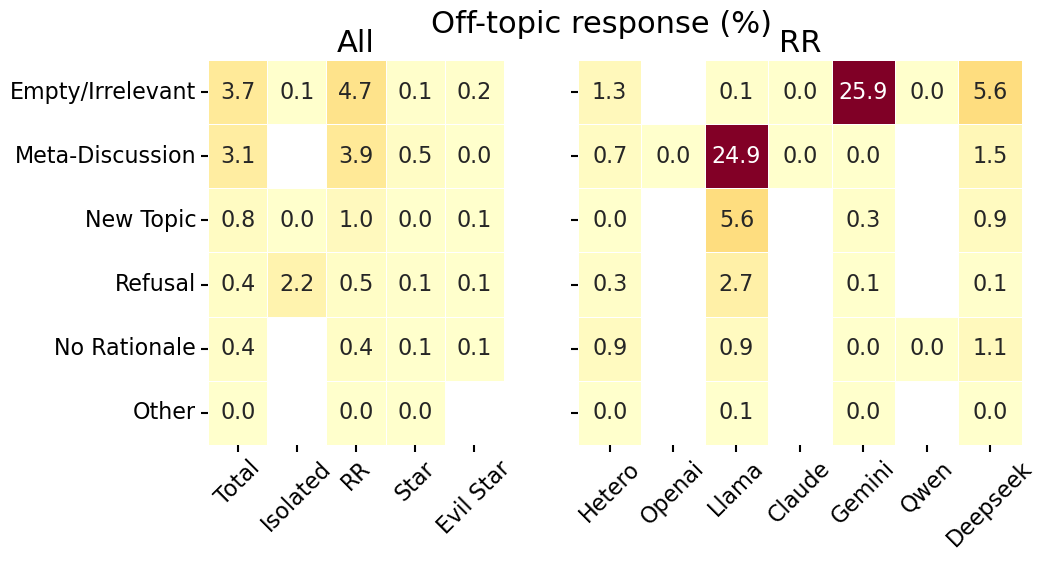

In [28]:
off_topic_plot = pivoted


# Draw a heatmap with the numeric values in each cell
fig, axs = plt.subplots(ncols = 2, figsize=(10.5, 5), sharey=True, gridspec_kw={'width_ratios': [2, 3]})
plt.suptitle('Off-topic response (%)', fontsize=text_size)
ax = axs[0]
hm = sns.heatmap(off_topic_plot, annot=True, fmt=".1f", linewidths=.5, ax=ax, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = False,vmin=0, vmax=25)
                 #cbar_kws = {'orientation':'horizontal', 'location':'bottom', 'pad':.25, 'fraction': .3})
hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)

ax.set_title('All', fontsize=text_size) 
ax.set_xlabel('')
ax.set_ylabel('')

ax1 = axs[1]
hm = sns.heatmap(pivoted_rr, annot=True, fmt=".1f", linewidths=.5, ax=ax1, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = False, vmin=0, vmax=25)
hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)
ax1.set_title('RR', fontsize=text_size) 
ax1.set_xlabel('')
ax1.set_ylabel('')


fig.savefig('figures/poster_off-topic.svg', bbox_inches='tight')

# Results - rationale 

## remove off topic responses

In [29]:
combined_df = combined_df[combined_df['is_response_off_topic'] == False]
exploded_df = exploded_df[exploded_df['is_response_off_topic'] == False]

## SKIP  (testing categories)

In [30]:
# mapped_categories = {
#     "UTILITARIAN_REASONING": "Utilitarian",
#     "DEONTOLOGICAL_REASONING": "Deontological",
#     "VIRTUE_ETHICS_REASONING": "Virtue Ethics",
#     "CARE_ETHICS_REASONING": "Care Ethics",
#     "FAIRNESS_JUSTICE_REASONING": "Fairness/Justice",
#     "AUTHORITY_BASED_REASONING": "Authority-Based",
#     "LOYALTY_BASED_INGROUP_REASONING": "Loyalty/Ingroup",
#     'LOYALTY_BAIZED_INGROUP_REASONING': "Loyalty/Ingroup", # misspelling
#     "LIBERTY_AUTONOMY_REASONING": "Liberty/Autonomy",
#     "PURITY_SANCTITY_REASONING": "Purity/Sanctity",
#     "HARM_AVOIDANCE_NON_MALEFICENCE": "Harm Avoidance",
#     "SELF_INTEREST_INDIVIDUAL_PRIORITY": "Self-Interest",
    

#     "PEER_PRESSURE_CONVERGENCE": "Peer Pressure",
#     "SYCOPHANCY_EXCESSIVE_AGREEMENT": "Sycophancy",
#     "MAINTAINING_DISSENT_INDEPENDENCE": "Dissent",
#     "EXPLICIT_DISAGREEMENT_COUNTER_ARGUMENT": "Dissent",
#     "CONVERGENCE_TO_SUPERVISOR_FRAMING": "Supervisor Converge",
#     "BUILDING_ON_OTHERS_REASONING": "Build on Others",
#     "PRAGMATIC_BALANCING_CONTEXTUAL": "Balancing",

#     "RISK_ASSESSMENT_PRECAUTIONARY": "Risk Assessment",
#     "LEGALISTIC_POLICY_BASED_REASONING": "Legalistic/Policy",
#     "META_REASONING_CLARIFICATION_FOCUS": "Meta Reasoning",
#     "ANALOGICAL_CASE_BASED_REASONING": "Analogical",
#     "RATIONALE_VAGUE_INCOMPLETE": "Vague/Incomplete",
#     "RATIONALE_CIRCULAR_RESTATING_ANSWER": "Circular",
#     "RATIONALE_TANGENTIAL_IRRELEVANT": "Tangential",
#     "NO_CLEAR_RATIONALE_PROVIDED": "No Rationale"
# }


In [31]:
### DO NOT DELETE #####

## mapping of categories for plotting (Ram's approach does leave around 118 uncategorized responses but this is a small number - we can make the number smaller to 40 if we also absorb : 
# <!-- 'COLLECTIVE_RESPONSIBILITY', 'COLLECTIVE_ACTION_REASONING', 
#                'ALTRUISM_COMMUNITY_RESPONSIBILITY',
#                'SOCIAL_RESPONSIBILITY','LOYALTY_BAIZED_INGROUP_REASONING']) -->

# or down to 83 jsut by including LOYALTY_BAIZED_INGROUP_REASONING

# ALSO TODO: MAKE SURE THAT THE SELECTED CATEGORIES ARE UPPERCASE!

In [32]:
## DO NOT DELETE #### 
# combined_df['selected_categories'].apply(lambda x: 'yes' if isinstance(x,list) else x).unique()

# make sure all selected categories nan is actually nan in answers (done and ok!)
# combined_df[combined_df['selected_categories'].isnull()]['answer'].unique()


In [33]:
# mapped = list(mapped_categories.keys())
# # 'COLLECTIVE_RESPONSIBILITY', 'COLLECTIVE_ACTION_REASONING', 
# #                'ALTRUISM_COMMUNITY_RESPONSIBILITY','SOCIAL_RESPONSIBILITY_ETHICS', 'SOCIAL_JUSTICE',
# #                'SOCIAL_RESPONSIBILITY','SHARED_HUMANITY', 'HUMAN_LIFE_PRESERVATION',
# # mapped.extend(['COLLECTIVE_ACTION_REASONING','SOCIAL_RESPONSIBILITY','COLLECTIVE_RESPONSIBILITY',
# #                'LOYALTY_BAIZED_INGROUP_REASONING'])
# test = combined_df.copy()

# test.dropna(subset = ['selected_categories'], inplace=True)

# # test[test['selected_categories'].isnull()] okay this is empty

# # check that there are no entries that do not have mapped categories 
# test['no category match'] = test['selected_categories'].apply(lambda x: not any([xi.upper() in mapped for xi in x]) if len(x)>0 else False)
# n_nomatch = len(test[test['no category match']])
# print(n_nomatch)
# test[test['no category match']]['group_model'].value_counts()
# test[test['no category match']]['group_type'].value_counts()

In [34]:
# exploded_test = test[test['no category match']].explode(['selected_categories'])
# exploded_test[exploded_test['selected_categories'] == 'BENEFICENCE_REASONING']['message_content'].unique()
# #test[test['no category match']]['selected_categories']

## Clean up categories and assign new Mappings (exploded_df) for Plotting

In [35]:
moral_categories = ["Utilitarian",
    "Deontological",
    "Virtue Ethics",
    "Care Ethics",
    "Fairness/Justice",
    "Authority-Based",
    "Loyalty/Ingroup",
    "Liberty/Autonomy",
    "Purity/Sanctity",
    "Harm Avoidance",
    "Self-Interest"]

moral_map = { "UTILITARIAN_REASONING": "Utilitarian",
    "DEONTOLOGICAL_REASONING": "Deontological",
    "VIRTUE_ETHICS_REASONING": "Virtue Ethics",
    "CARE_ETHICS_REASONING": "Care Ethics",
    "FAIRNESS_JUSTICE_REASONING": "Fairness/Justice",
    "AUTHORITY_BASED_REASONING": "Authority-Based",
    "LOYALTY_BASED_INGROUP_REASONING": "Loyalty/Ingroup",
    'LOYALTY_BAIZED_INGROUP_REASONING': "Loyalty/Ingroup", # misspelling
    "LIBERTY_AUTONOMY_REASONING": "Liberty/Autonomy",
    "PURITY_SANCTITY_REASONING": "Purity/Sanctity",
    "HARM_AVOIDANCE_NON_MALEFICENCE": "Harm Avoidance",
    "SELF_INTEREST_INDIVIDUAL_PRIORITY": "Self-Interest"
    }


interaction_categories = ["Peer Pressure",
    "Sycophancy",
    "Dissent",
    "Supervisor Converge",
    "Build on Others",
    "Balancing"]

interaction_map = { "PEER_PRESSURE_CONVERGENCE": "Peer Pressure",
    "SYCOPHANCY_EXCESSIVE_AGREEMENT": "Sycophancy",
    "MAINTAINING_DISSENT_INDEPENDENCE": "Dissent",
    "EXPLICIT_DISAGREEMENT_COUNTER_ARGUMENT": "Dissent",
    "CONVERGENCE_TO_SUPERVISOR_FRAMING": "Supervisor Converge",
    "BUILDING_ON_OTHERS_REASONING": "Build on Others",
    "PRAGMATIC_BALANCING_CONTEXTUAL": "Balancing"
    }

reasoning_categories = ["Risk Assessment",
    "Legalistic/Policy",
    "Meta Reasoning",
    "Analogical",
    "Vague/Incomplete",
    "Circular",
    "Tangential",
    "No Rationale"]

reasoning_map = {"RISK_ASSESSMENT_PRECAUTIONARY": "Risk Assessment",
    "LEGALISTIC_POLICY_BASED_REASONING": "Legalistic/Policy",
    "META_REASONING_CLARIFICATION_FOCUS": "Meta Reasoning",
    "ANALOGICAL_CASE_BASED_REASONING": "Analogical",
    "RATIONALE_VAGUE_INCOMPLETE": "Vague/Incomplete",
    "RATIONALE_CIRCULAR_RESTATING_ANSWER": "Circular",
    "RATIONALE_TANGENTIAL_IRRELEVANT": "Tangential",
    "NO_CLEAR_RATIONALE_PROVIDED": "No Rationale"
    }

mapped_categories = {**moral_map, **reasoning_map, **interaction_map}

all_categories = moral_categories + reasoning_categories + interaction_categories

In [36]:
exploded_df['plot_category_label'] = exploded_df['selected_categories'].apply(lambda x: mapped_categories.get(x, x))

In [37]:
# There's still 400 extra entries in combined_df when compared to exploded df... when calculating percentages
# Even after accounting for empty lists and that we dropped nans and empty categories
test_for_combined = exploded_df.copy()
test_for_combined.drop(columns=['selected_categories', 'plot_category_label'],inplace=True)
test_for_combined.drop_duplicates(inplace=True)

a = len(test_for_combined) -   len(combined_df[combined_df['selected_categories'].apply(lambda x: len(x) > 0 and x is not None)])
b = len(test_for_combined) - len(combined_df)

print(f'difference after nan drop: {a}, before nan drop: {b}')

difference after nan drop: -399, before nan drop: -897


## Topological groupings

In [38]:
# exploded dfs
exploded_df
n_total = len(combined_df)

# single exploded 
single_explo = exploded_df[exploded_df['group_type'] == 'isolated']
n_single = len(combined_df[combined_df['group_type'] == 'isolated'])

# rr all exploded 
rr_explo= exploded_df[exploded_df['group_type'] == 'ring']
n_rr = len(combined_df[combined_df['group_type'] == 'ring'])

# star (non-evil) exploded 
star_explo = exploded_df[(exploded_df['group_type'] == 'star') & (exploded_df['group_evil'] == False)]
n_star = len(combined_df[(combined_df['group_type'] == 'star') & (combined_df['group_evil'] == False)])

# star (evil) exploded
evil_star_explo = exploded_df[(exploded_df['group_type'] == 'star') & (exploded_df['group_evil'] == True)]
n_evil_star = len(combined_df[(combined_df['group_type'] == 'star') & (combined_df['group_evil'] == True)])

# List of dataframes for overview heatman
group_label_list = ['Total', 'Isolated', 'RR', 'Star', 'Evil Star']
group_size_list = [n_total, n_single, n_rr, n_star, n_evil_star]
group_df_list = [exploded_df, single_explo, rr_explo, star_explo, evil_star_explo]

# list of dataframes for round robin only heatmap
rr_group_label_list =[]
rr_group_size_list = [] # [n_rr_comb]
rr_group_df_list = [] # [ex_rr_comb]

for model in combined_df['group_model'].unique():
   this_df = exploded_df[(exploded_df['group_type'] == 'ring') & (exploded_df['group_model'] == model)].copy()
   this_n = len(combined_df[(combined_df['group_type'] == 'ring') & (combined_df['group_model'] == model)])
   rr_group_df_list.append(this_df)
   rr_group_size_list.append(this_n)
   if model == 'mixed':
    rr_group_label_list.append('Hetero')
   else:
    rr_group_label_list.append(model.capitalize())
   del this_df
   del this_n    

## heatmap overview

In [ ]:
# heatmap for overview of all off-topic responses
all_cats_heatmap = pd.DataFrame()
for i in range(len(group_label_list)):
    group_label = group_label_list[i]
    group_size = group_size_list[i]
    group_df = group_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_category_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    all_cats_heatmap = pd.concat([all_cats_heatmap, df], ignore_index=True)


# pivot the dataframe for heatmap - also need to reindex for presentation
all_cats_heatmap['group'] = all_cats_heatmap['group'].apply(lambda x: 'RT STAR\n(GPT)' if x=='RT Star' else x)
pivoted = all_cats_heatmap.pivot(index="plot_category_label", columns="group", values="percentage")
pivoted = pivoted.reindex(columns=['Total','Isolated', 'RR', 'Star', 'RT Star\n(GPT)'])
pivoted = pivoted.reindex(index= all_categories)


In [40]:
all_cats_heatmap['group']

0                 Total
1                 Total
2                 Total
3                 Total
4                 Total
             ...       
411    Evil Star\n(GPT)
412    Evil Star\n(GPT)
413    Evil Star\n(GPT)
414    Evil Star\n(GPT)
415    Evil Star\n(GPT)
Name: group, Length: 416, dtype: object

In [41]:
# heatmap for round roubin specifically
heatmap_rr_df = pd.DataFrame()
for i in range(len(rr_group_label_list)):
    group_label = rr_group_label_list[i]
    group_size = rr_group_size_list[i]
    group_df = rr_group_df_list[i]
    
    # Convert counts to DataFrame
    df = counts_to_df(group_df['plot_category_label'].value_counts(), group_label, group_size)
    
    # Append to the main DataFrame
    heatmap_rr_df = pd.concat([heatmap_rr_df, df], ignore_index=True)

# pivot the dataframe for heatmap
pivoted_rr = heatmap_rr_df.pivot(index="plot_category_label", columns="group", values="percentage")
pivoted_rr = pivoted_rr.reindex(columns=['Hetero', 'Openai', 'Llama', 'Claude', 'Gemini', 'Qwen', 'Deepseek'])
pivoted_rr = pivoted_rr.reindex(index=all_categories)



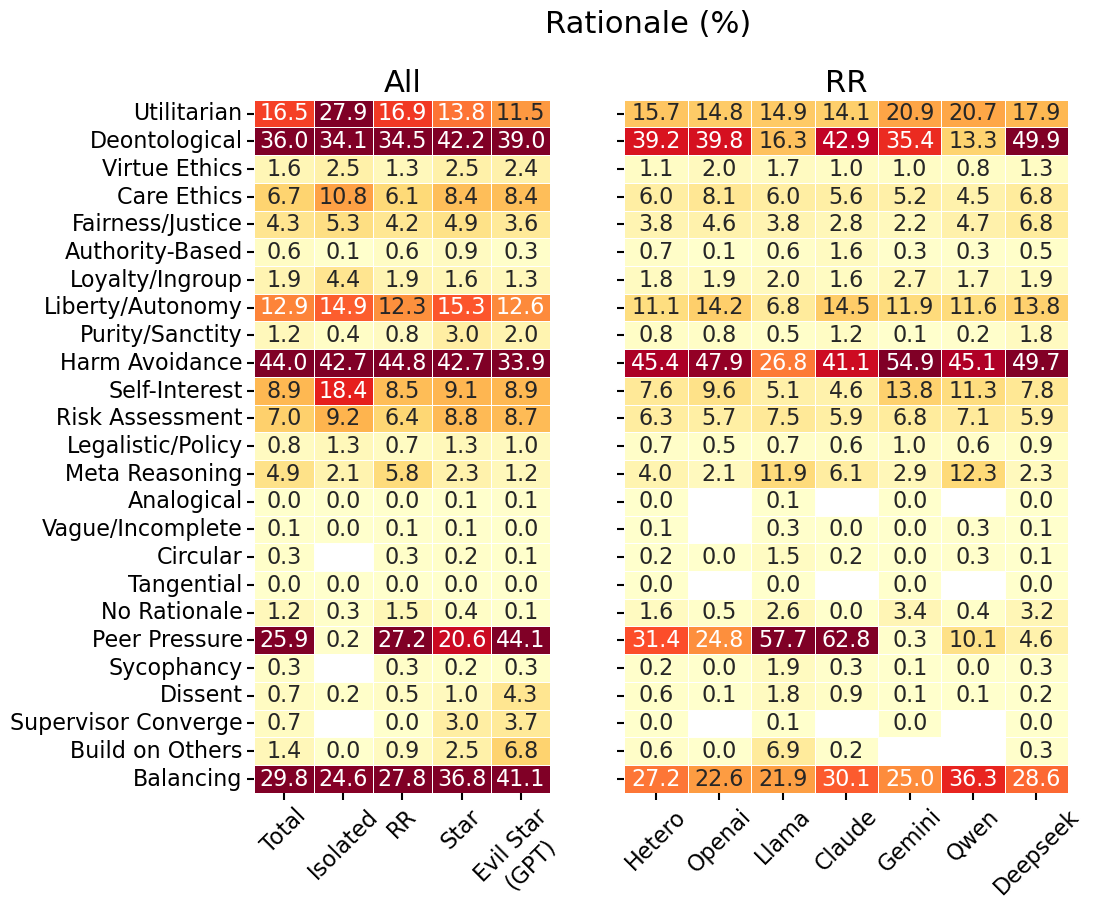

In [42]:
off_topic_plot = pivoted



# Draw a heatmap with the numeric values in each cell
fig, axs = plt.subplots(ncols = 2, figsize=(10.5, 9), sharey=True, gridspec_kw={'width_ratios': [2, 3]})


plt.suptitle('Rationale (%)', fontsize=text_size)
ax = axs[0]
hm = sns.heatmap(off_topic_plot, annot=True, fmt=".1f", linewidths=.5, ax=ax, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = False,vmin=0, vmax=25)
                 #cbar_kws = {'orientation':'horizontal', 'location':'bottom', 'pad':.25, 'fraction': .3})
hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)

ax.set_title('All', fontsize=text_size) 
ax.set_xlabel('')
ax.set_ylabel('')

ax1 = axs[1]
hm = sns.heatmap(pivoted_rr, annot=True, fmt=".1f", linewidths=.5, ax=ax1, 
                 cmap='YlOrRd',annot_kws={"size": tick_size},cbar = False, vmin=0, vmax=50)
hm.tick_params(labelsize=tick_size)
hm.set_xticklabels(hm.get_xticklabels(), rotation=45)
ax1.set_title('RR', fontsize=text_size) 
ax1.set_xlabel('')
ax1.set_ylabel('')


fig.savefig('figures/all_and_rr.svg', bbox_inches='tight')

In [43]:
# 1. Heterogeneous ring groups (mixed models)
hetero_exploded = exploded_df[
    (exploded_df['group_type'] == 'ring') & 
    (exploded_df['group_model'] == 'mixed') &
    (exploded_df['group_evil'] == False)
]
hetero_combined = combined_df[
    (combined_df['group_type'] == 'ring') & 
    (combined_df['group_model'] == 'mixed') &
    (combined_df['group_evil'] == False)
]

# 2. Star topology (non-evil, non-inverted, homogeneous)
star_exploded = exploded_df[
    (exploded_df['group_type'] == 'star') & 
    (exploded_df['group_evil'] == False) &
    (exploded_df['group_model'] == 'openai')
]
star_combined = combined_df[
    (combined_df['group_type'] == 'star') & 
    (combined_df['group_evil'] == False) &
    (combined_df['group_model'] == 'openai')
]

# 3. OpenAI homogeneous groups (single + ring homo)
openai_exploded = exploded_df[
    (
     ((exploded_df['group_type'] == 'ring') & (exploded_df['group_model'] != 'mixed'))) &
    (exploded_df['group_model'] == 'openai') &
    (exploded_df['group_evil'] == False)
]
openai_combined = combined_df[
    (
     ((combined_df['group_type'] == 'ring') & (combined_df['group_model'] != 'mixed'))) &
    (combined_df['group_model'] == 'openai') &
    (combined_df['group_evil'] == False)
]

print(f"Hetero data: {len(hetero_exploded)} exploded, {len(hetero_combined)} combined")
print(f"Star data: {len(star_exploded)} exploded, {len(star_combined)} combined")
print(f"OpenAI data: {len(openai_exploded)} exploded, {len(openai_combined)} combined")

Hetero data: 103272 exploded, 50132 combined
Star data: 115128 exploded, 51391 combined
OpenAI data: 103699 exploded, 51798 combined
